In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import cv2
import os

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
print("GPUs:", gpus)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2
OpenCV version: 4.13.0
GPU available: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install kagglehub -q

import kagglehub
import os

dataset_path = kagglehub.dataset_download("msambare/fer2013")

print("Dataset downloaded to:", dataset_path)
print("Files and folders:")
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded to: /kaggle/input/fer2013
Files and folders:
['test', 'train']


In [3]:
import os
from collections import Counter

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

print("\nTrain classes:")
print(os.listdir(train_dir))

print("\nTest classes:")
print(os.listdir(test_dir))

Train folder exists: True
Test folder exists: True

Train classes:
['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']

Test classes:
['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [4]:
def count_images_by_class(folder_path):
    class_counts = {}

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            num_images = len([
                file for file in os.listdir(class_path)
                if file.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            class_counts[class_name] = num_images

    return class_counts


train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

print("Training set image counts:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nTest set image counts:")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")

Training set image counts:
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171

Test set image counts:
angry: 958
disgust: 111
fear: 1024
happy: 1774
neutral: 1233
sad: 1247
surprise: 831


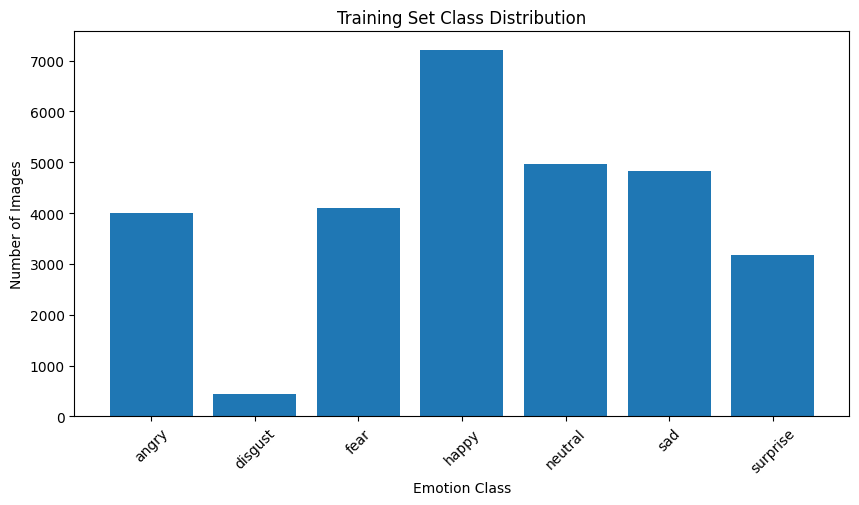

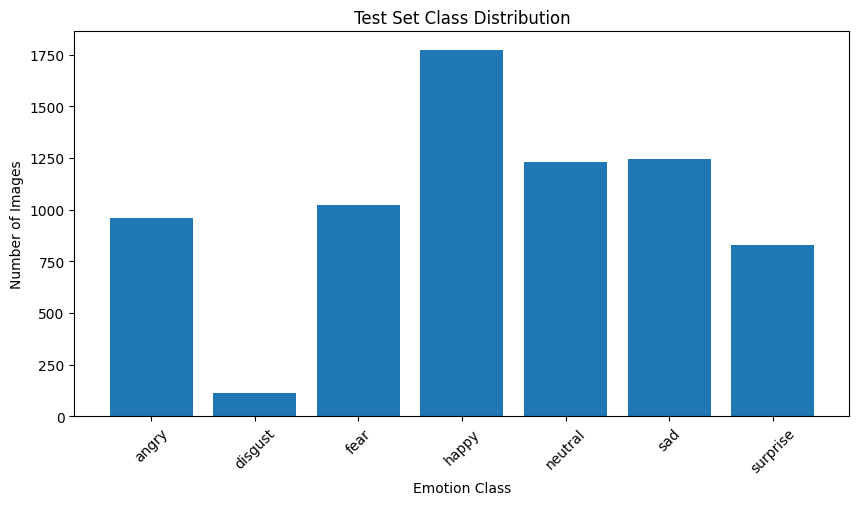

In [5]:
import matplotlib.pyplot as plt

classes = list(train_counts.keys())
train_values = list(train_counts.values())
test_values = list(test_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(classes, train_values)
plt.title("Training Set Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(classes, test_values)
plt.title("Test Set Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

Sample image path: /kaggle/input/fer2013/train/happy/Training_16674696.jpg
Image shape: (48, 48)
Pixel value range: 29 to 243


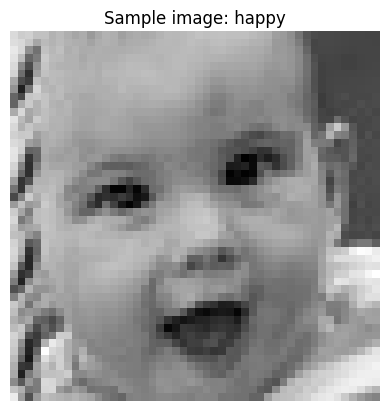

In [6]:
import cv2
import random

sample_class = "happy"
sample_folder = os.path.join(train_dir, sample_class)

sample_file = random.choice(os.listdir(sample_folder))
sample_path = os.path.join(sample_folder, sample_file)

image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print("Sample image path:", sample_path)
print("Image shape:", image.shape)
print("Pixel value range:", image.min(), "to", image.max())

plt.imshow(image, cmap="gray")
plt.title(f"Sample image: {sample_class}")
plt.axis("off")
plt.show()

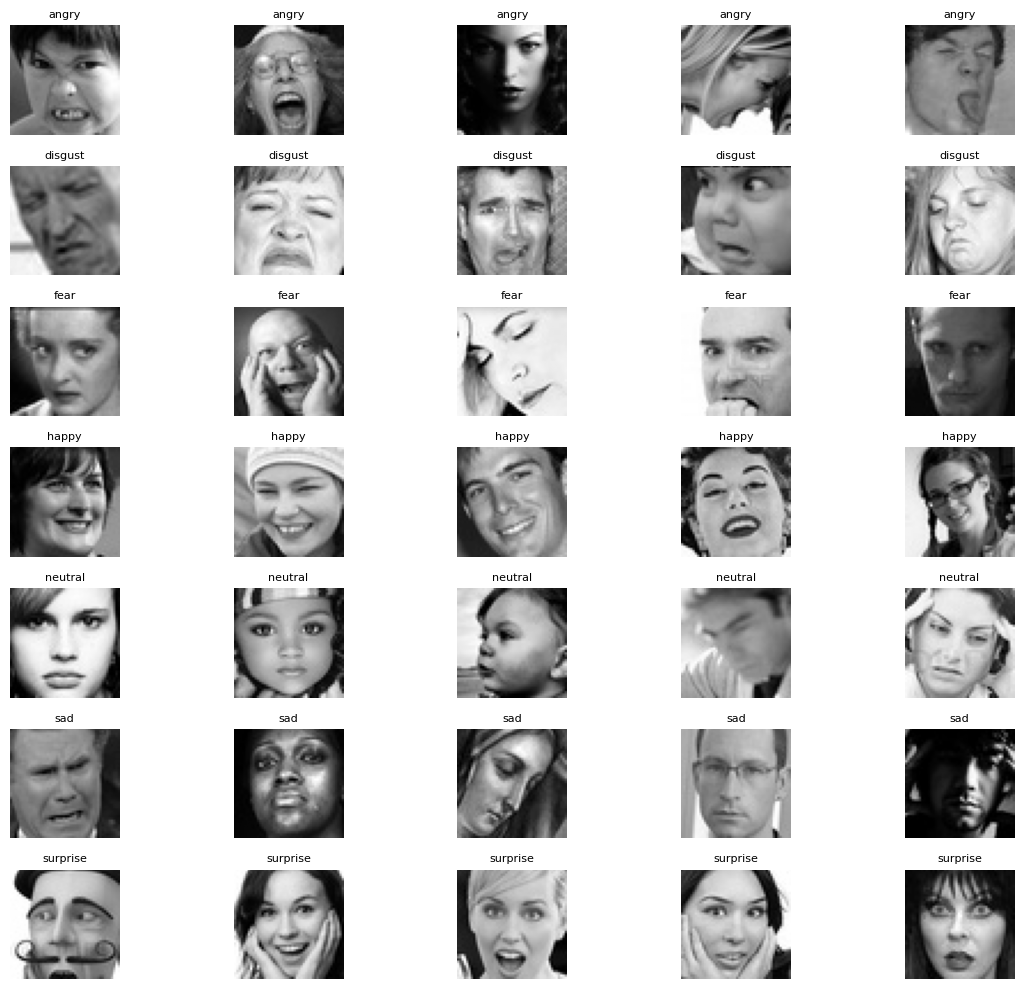

In [7]:
num_samples_per_class = 5
class_names = sorted(os.listdir(train_dir))

plt.figure(figsize=(12, 10))

plot_index = 1

for class_name in class_names:
    class_folder = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_folder)
    selected_files = random.sample(image_files, num_samples_per_class)

    for file_name in selected_files:
        image_path = os.path.join(class_folder, file_name)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(len(class_names), num_samples_per_class, plot_index)
        plt.imshow(image, cmap="gray")
        plt.title(class_name, fontsize=8)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.2932 - loss: 1.7496 - val_accuracy: 0.3635 - val_loss: 1.6005
Epoch 2/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4092 - loss: 1.5329 - val_accuracy: 0.4564 - val_loss: 1.4086
Epoch 3/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4613 - loss: 1.4026 - val_accuracy: 0.5030 - val_loss: 1.3226
Epoch 4/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4963 - loss: 1.3217 - val_accuracy: 0.5179 - val_loss: 1.2652
Epoch 5/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5199 - loss: 1.2605 - val_accuracy: 0.5342 - val_loss: 1.2263
Epoch 6/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5488 - loss: 1.1981 - val_accuracy: 0.5349 - val_loss: 1.2122
Epoch 7/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5673 - loss: 1.1425 - val_accuracy: 0.5504 - val_loss: 1.1941
Epoch 8/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5891 - loss: 1.0896 - val_accuracy: 

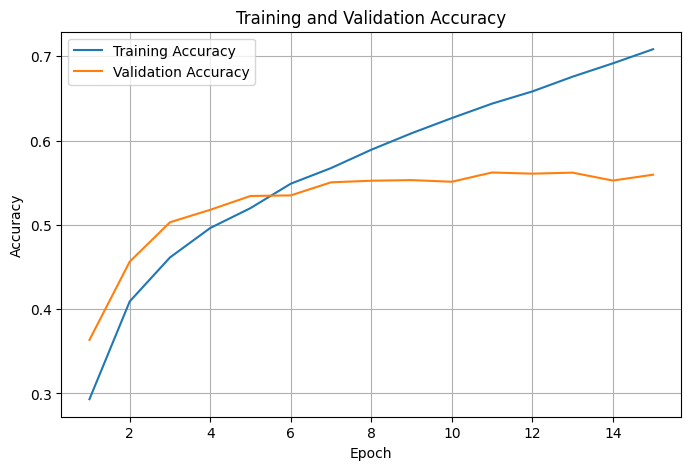

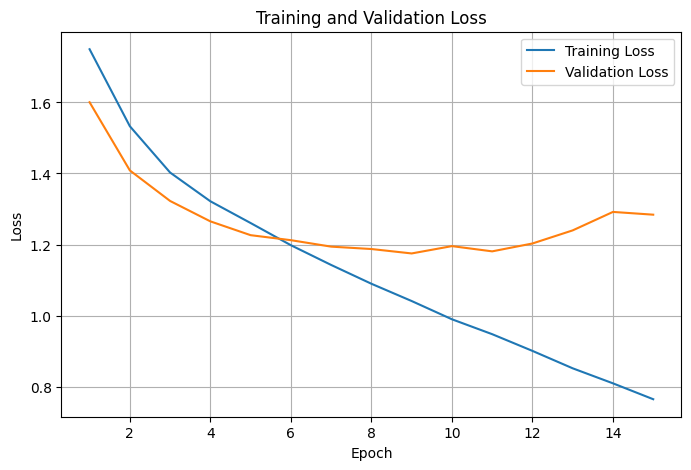

In [12]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 0.5573 - loss: 1.2875
Test accuracy: 0.5572583079338074
Test loss: 1.2875131368637085


In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Confusion Matrix:
[[ 486    1   71   88  106  178   28]
 [  37   36   13    6    2   17    0]
 [ 162    3  321   81   96  256  105]
 [  83    1   30 1401  130   92   37]
 [ 117    3   70  138  557  330   18]
 [ 183    1  123  109  188  614   29]
 [  50    1   93   56   24   22  585]]

Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.51      0.47       958
     disgust       0.78      0.32      0.46       111
        fear       0.45      0.31      0.37      1024
       happy       0.75      0.79      0.77      1774
     neutral       0.50      0.45      0.48      1233
         sad       0.41      0.49      0.45      1247
    surprise       0.73      0.70      0.72       831

    accuracy                           0.56      7178
   macro avg       0.58      0.51      0.53      7178
weighted avg       0.56      0.56      0.55      7178



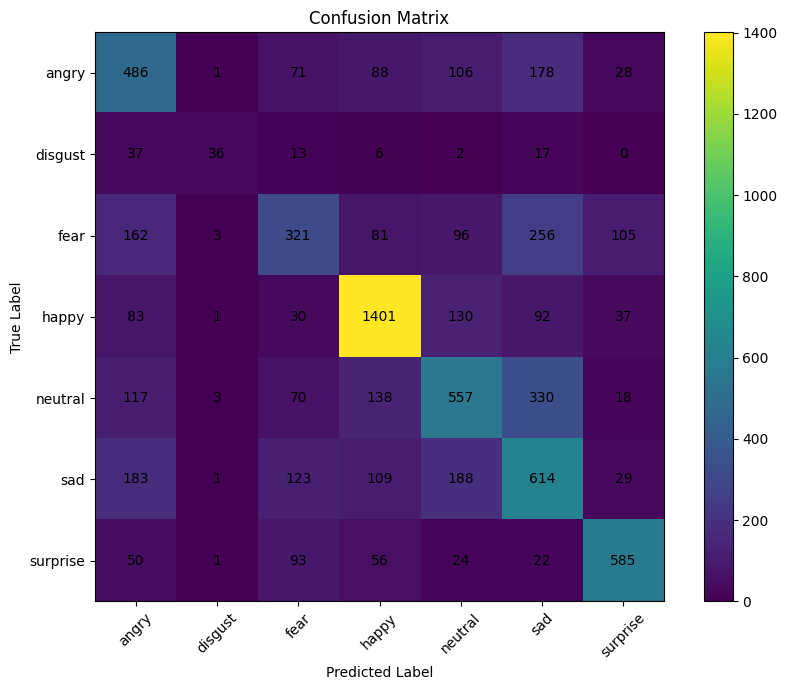

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [16]:
import os

os.makedirs("results", exist_ok=True)

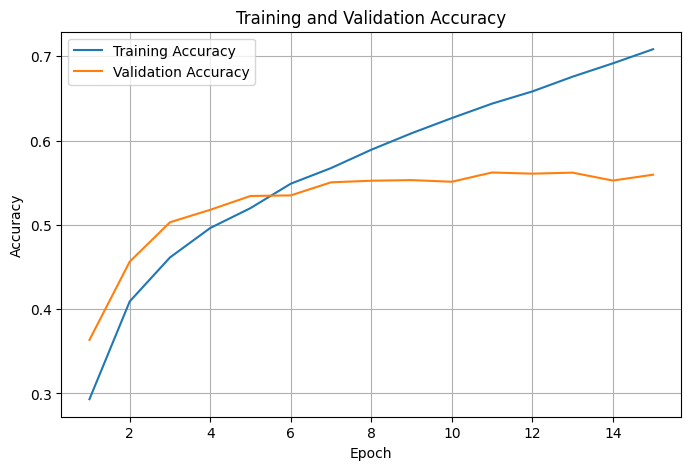

In [17]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("results/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

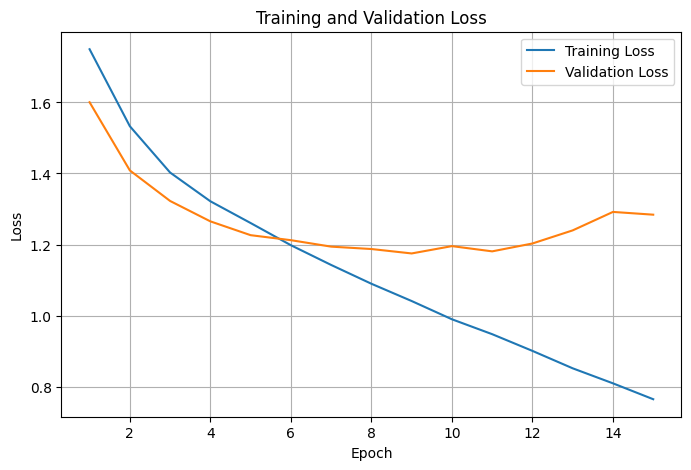

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

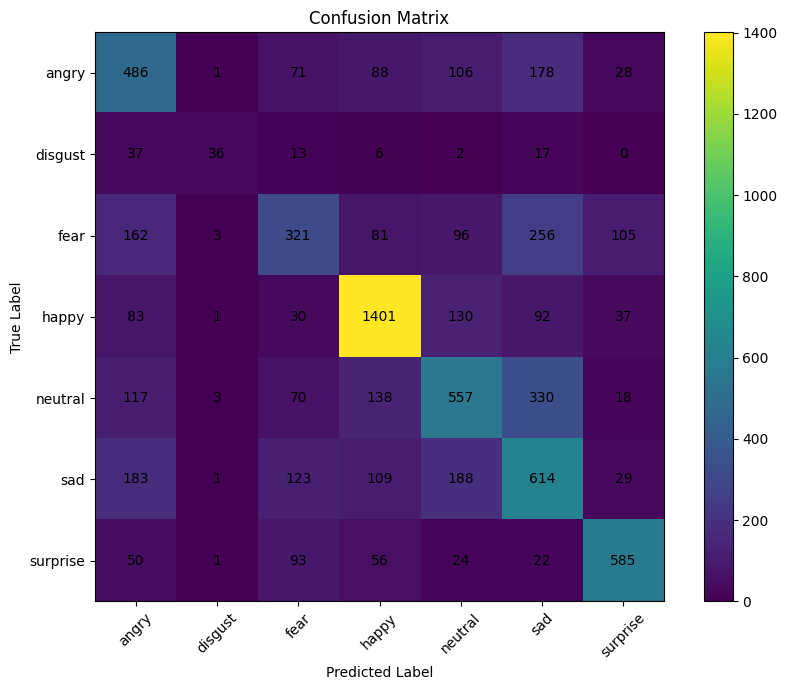

In [19]:
plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
with open("results/experiment_summary.txt", "w") as f:
    f.write("Facial Expression Recognition CNN Baseline\n")
    f.write("-----------------------------------------\n")
    f.write(f"Training accuracy: {acc[-1]:.4f}\n")
    f.write(f"Validation accuracy: {val_acc[-1]:.4f}\n")
    f.write(f"Training loss: {loss[-1]:.4f}\n")
    f.write(f"Validation loss: {val_loss[-1]:.4f}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test loss: {test_loss:.4f}\n")

In [21]:
import os

print(os.listdir("results"))

['accuracy_curve.png', 'experiment_summary.txt', 'confusion_matrix.png', 'loss_curve.png']


In [22]:
with open("results/experiment_summary.txt", "r") as file:
    print(file.read())

Facial Expression Recognition CNN Baseline
-----------------------------------------
Training accuracy: 0.7083
Validation accuracy: 0.5595
Training loss: 0.7647
Validation loss: 1.2840
Test accuracy: 0.5573
Test loss: 1.2875



In [23]:
model.save("results/fer_cnn_baseline.keras")

print("Model saved successfully.")

Model saved successfully.


In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

with open("results/classification_report.txt", "w") as file:
    file.write(report)

print(report)

              precision    recall  f1-score   support

       angry       0.43      0.51      0.47       958
     disgust       0.78      0.32      0.46       111
        fear       0.45      0.31      0.37      1024
       happy       0.75      0.79      0.77      1774
     neutral       0.50      0.45      0.48      1233
         sad       0.41      0.49      0.45      1247
    surprise       0.73      0.70      0.72       831

    accuracy                           0.56      7178
   macro avg       0.58      0.51      0.53      7178
weighted avg       0.56      0.56      0.55      7178



In [25]:
print(os.listdir("results"))

['accuracy_curve.png', 'fer_cnn_baseline.keras', 'classification_report.txt', 'experiment_summary.txt', 'confusion_matrix.png', 'loss_curve.png']


In [26]:
import os
import zipfile

result_files = [
    "results/accuracy_curve.png",
    "results/loss_curve.png",
    "results/confusion_matrix.png",
    "results/experiment_summary.txt",
    "results/classification_report.txt",
    "results/fer_cnn_baseline.keras"
]

print("Files to package:")
for file_path in result_files:
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"{file_path}: {size_mb:.2f} MB")
    else:
        print(f"Missing: {file_path}")

with zipfile.ZipFile("fer_cnn_results.zip", "w") as zip_file:
    for file_path in result_files:
        if os.path.exists(file_path):
            zip_file.write(
                file_path,
                arcname=os.path.basename(file_path)
            )

print("\nCreated fer_cnn_results.zip")

Files to package:
results/accuracy_curve.png: 0.12 MB
results/loss_curve.png: 0.12 MB
results/confusion_matrix.png: 0.21 MB
results/experiment_summary.txt: 0.00 MB
results/classification_report.txt: 0.00 MB
results/fer_cnn_baseline.keras: 7.87 MB

Created fer_cnn_results.zip


In [27]:
from google.colab import files

files.download("fer_cnn_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>